In [20]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# 将项目根目录加入 Path
project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from analysis.plot_utils import (
    load_experiment_data, 
    load_experiment_configs,
    plot_time_series, 
    plot_action_distribution, 
    plot_single_run_cycles,
    plot_metric_for_specific_n,
    plot_action_share_for_specific_n
)
from src.environment import compute_nash_and_monopoly_static

print("Libraries loaded. Ready to analyze.")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Libraries loaded. Ready to analyze.


In [ ]:
# === 配置 ===
# 选择你想看的实验名字
# 选项: 
# 1. "exp_1_classic_mu025"
# 2. "exp_2_classic_mu002"
# 3. "exp_3_reset_mu025"
# 4. "exp_4_reset_mu002"

EXP_NAME = "exp_1_classic_mu025"
# 加载数据
# downsample_rate=1000 表示每 1000 行取 1 行。
# 对于 T=1,000,000，这会留下 1,000 个点，画图足够清晰且极快。
df = load_experiment_data(EXP_NAME, downsample_rate=1000)

configs = load_experiment_configs(EXP_NAME)

df.head()

Loading 200 files from exp_2_classic_mu002...
Loaded successfully. Total rows: 200,000
Loaded 4 configs for N=[2, 3, 4, 5]


,run_id,t,lowest_price,average_price,delta,is_converged,p_0,a_0,pi_0,p_1,...,p_2,a_2,pi_2,n_sellers,p_3,a_3,pi_3,p_4,a_4,pi_4
0,46,0,1.426626,1.630021,0.374859,False,1.548663,2,0.071106,1.914775,...,1.426626,2.0,0.071106,3,NaN,NaN,NaN,NaN,NaN,NaN
1,46,1000,0.938476,1.019834,-0.101626,False,0.938476,1,-0.030558,1.060513,...,1.060513,1.0,-0.030558,3,NaN,NaN,NaN,NaN,NaN,NaN
2,46,2000,0.938476,0.938476,-0.101626,False,0.938476,2,0.000135,0.938476,...,0.938476,2.0,0.000135,3,NaN,NaN,NaN,NaN,NaN,NaN
3,46,3000,0.938476,0.938476,-0.102082,False,0.938476,1,-0.030728,0.938476,...,0.938476,2.0,0.000068,3,NaN,NaN,NaN,NaN,NaN,NaN
4,46,4000,2.036813,2.036813,-0.004104,False,2.036813,2,0.000079,2.036813,...,2.036813,0.0,0.013125,3,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
# Print: In the last 1% of the 't', on average, for each n_sellers, what proportion of the runs convereged (with is_converged==True)?
convergence_summary = df[df['t'] >= df['t'].max() * 0.99].groupby('n_sellers')['is_converged'].mean().reset_index()
print(convergence_summary)

   n_sellers  is_converged
0          2         0.786
1          3         1.000
2          4         0.992
3          5         0.874


In [23]:
# Compute nash and monopoly benchmarks
# { n_sellers: (p_nash, p_mon) }
benchmarks = {}

sorted_ns = sorted(configs.keys())
print(f"Calculating benchmarks for N={sorted_ns}...")

for n in sorted_ns:
    cfg = configs[n]
    
    # 调用静态函数计算
    p_nash, p_mon = compute_nash_and_monopoly_static(
        num_sellers=n,
        a_val=cfg["a_val"],
        mu=cfg["mu"],
        a0=cfg["a0"],
        c_val=cfg["c_val"]
    )
    
    benchmarks[n] = (p_nash, p_mon)
    print(f"  N={n}: Nash={p_nash:.3f}, Monopoly={p_mon:.3f}")

Calculating benchmarks for N=[2, 3, 4, 5]...
  N=2: Nash=1.040, Monopoly=1.937
  N=3: Nash=1.030, Monopoly=1.945
  N=4: Nash=1.027, Monopoly=1.951
  N=5: Nash=1.025, Monopoly=1.955


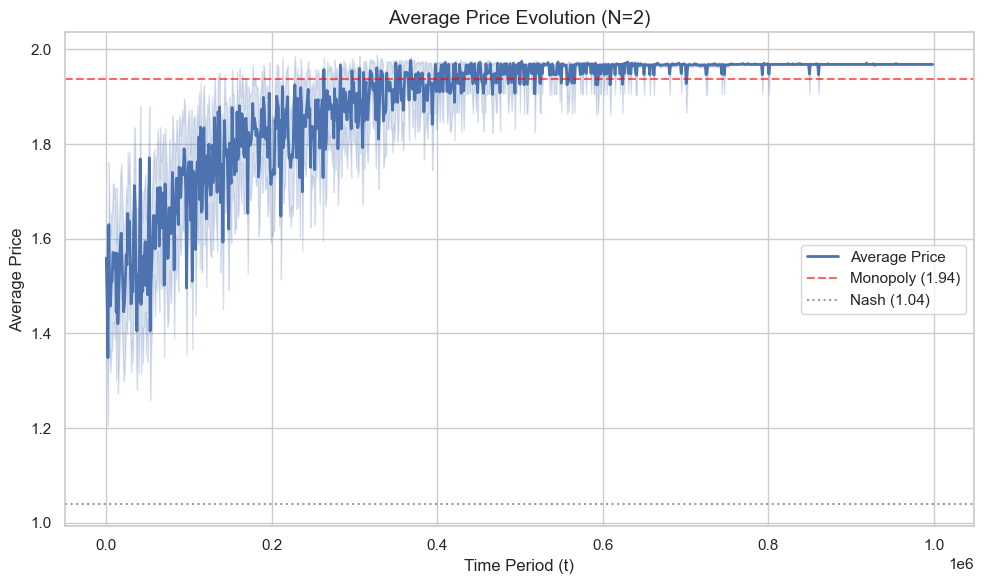

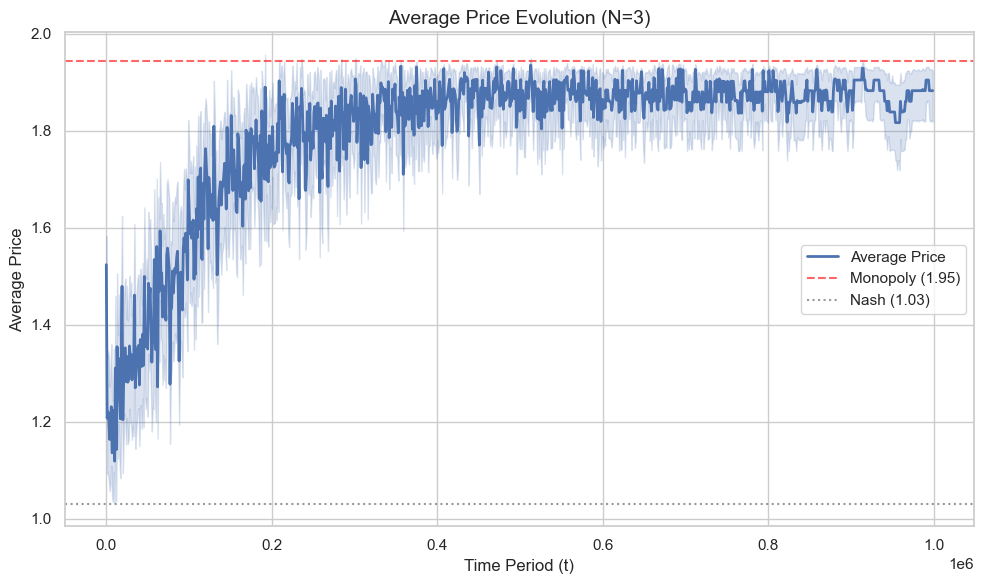

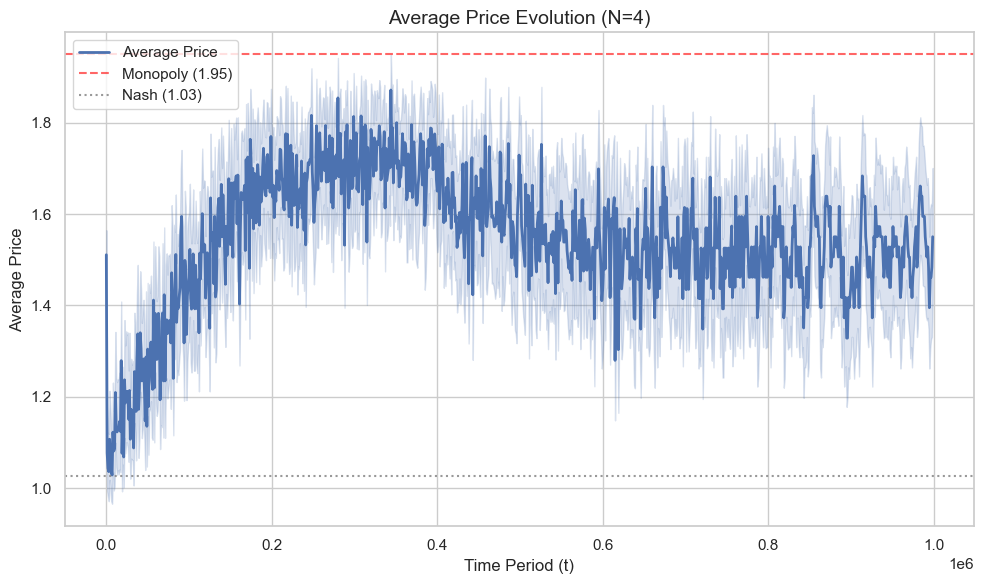

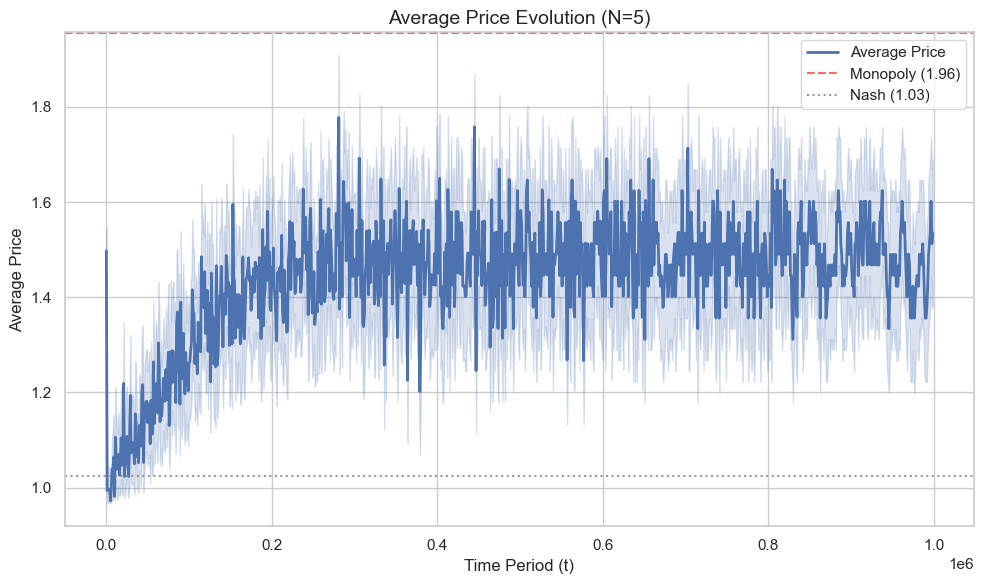

In [24]:
if df is not None:
    # 原始 average_price 绘图已注释保留
    # all_ns = sorted(df["n_sellers"].unique())
    # for n in all_ns:
    #     p_nash, p_mon = benchmarks.get(n, (None, None))
    #     plot_metric_for_specific_n(
    #         df=df,
    #         n_sellers=n,
    #         y_col="average_price",
    #         title=f"Average Price Evolution (N={n})",
    #         ylabel="Average Price",
    #         smoothing=1,
    #         ci=95,
    #         nash_price=p_nash,
    #         monopoly_price=p_mon
    #     )

    # 新：绘制平均 K 步价格
    all_ns = sorted(df["n_sellers"].unique())
    for n in all_ns:
        p_nash, p_mon = benchmarks.get(n, (None, None))
        plot_metric_for_specific_n(
            df=df,
            n_sellers=n,
            y_col="average_K_price",
            title=f"Average K-Step Price (N={n})",
            ylabel="Average K-Step Price",
            smoothing=1,
            ci=95,
            nash_price=p_nash,
            monopoly_price=p_mon
        )


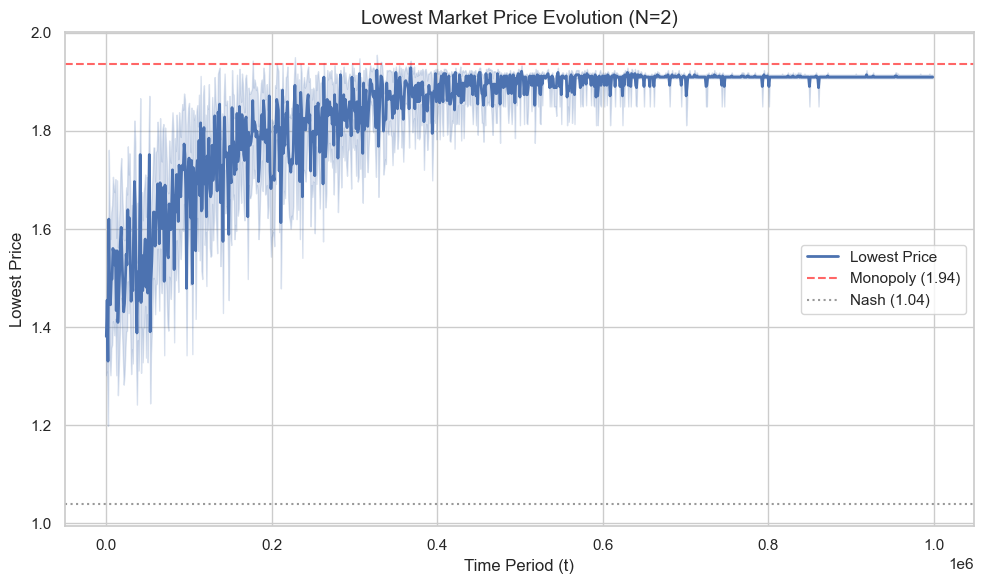

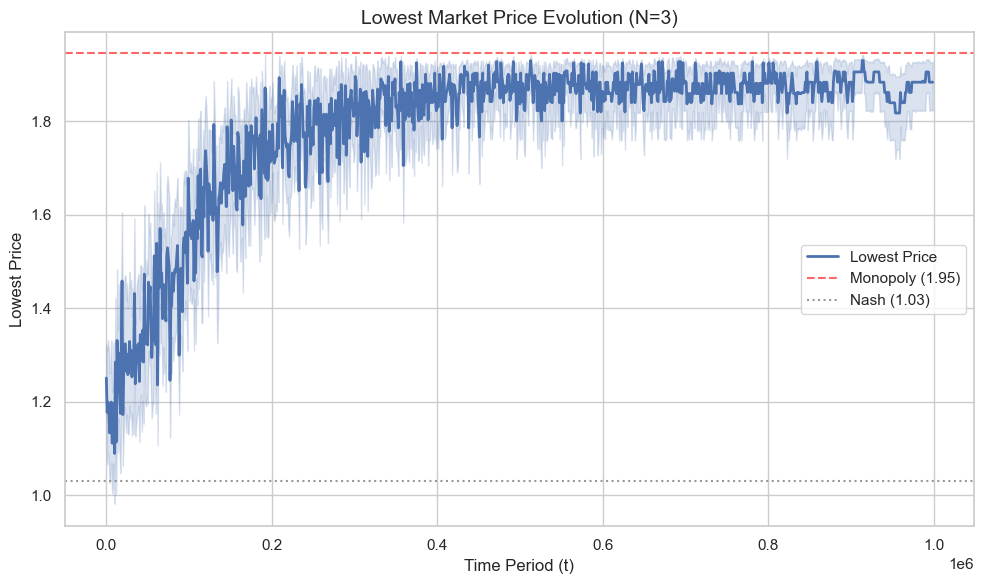

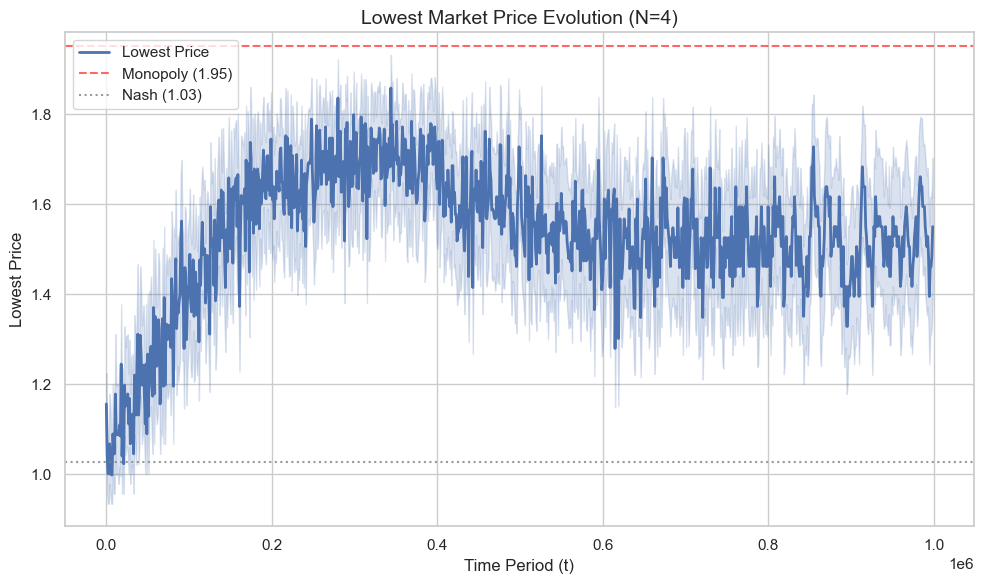

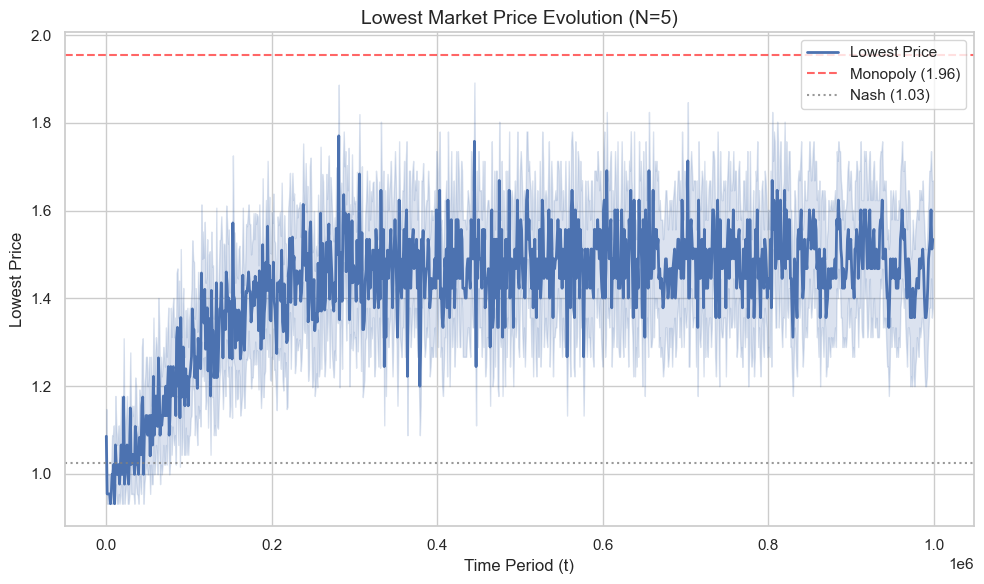

In [ ]:
# Plot Lowest Price Evolution
if df is not None and "lowest_price" in df.columns:
    # 原始 lowest_price 绘图已注释保留
    # for n in sorted(df["n_sellers"].unique()):
    #     p_nash, p_mon = benchmarks.get(n, (None, None))
    #     plot_metric_for_specific_n(
    #         df=df,
    #         n_sellers=n,
    #         y_col="lowest_price",
    #         title=f"Lowest Market Price Evolution (N={n})",
    #         ylabel="Lowest Price",
    #         smoothing=1,
    #         ci=95,
    #         nash_price=p_nash,
    #         monopoly_price=p_mon
    #     )
    pass

# 新：绘制平均 K 步最低价格
for n in sorted(df["n_sellers"].unique()):
    p_nash, p_mon = benchmarks.get(n, (None, None))
    plot_metric_for_specific_n(
        df=df,
        n_sellers=n,
        y_col="average_lowest_K_price",
        title=f"Average K-Step Lowest Price (N={n})",
        ylabel="Average K-Step Lowest Price",
        smoothing=1,
        ci=95,
        nash_price=p_nash,
        monopoly_price=p_mon
    )


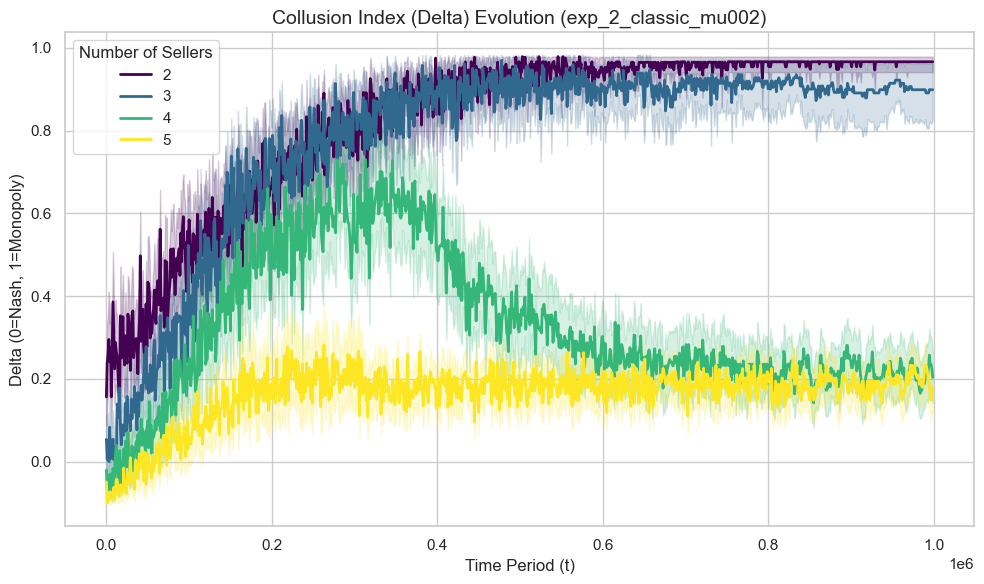

In [ ]:
if df is not None and not df.empty:
    plot_time_series(
        df, 
        y_col="delta", 
        title=f"Collusion Index ($\Delta$) Evolution ({EXP_NAME})", 
        ylabel="$\Delta$ (0=Nash, 1=Monopoly)",
        hue="n_sellers",
        smoothing=1,
        ci=95
    )

Plotting Action Shares for each N...


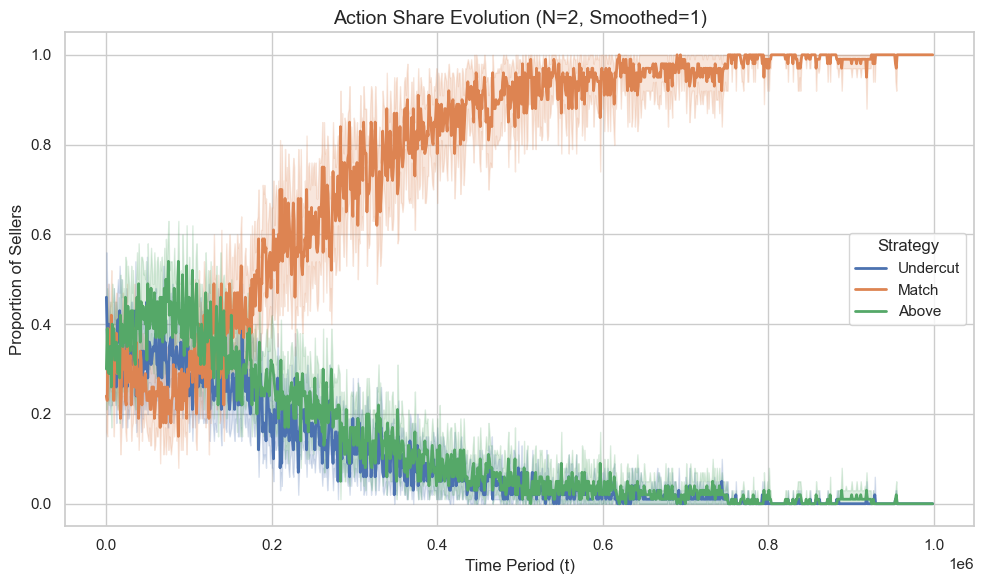

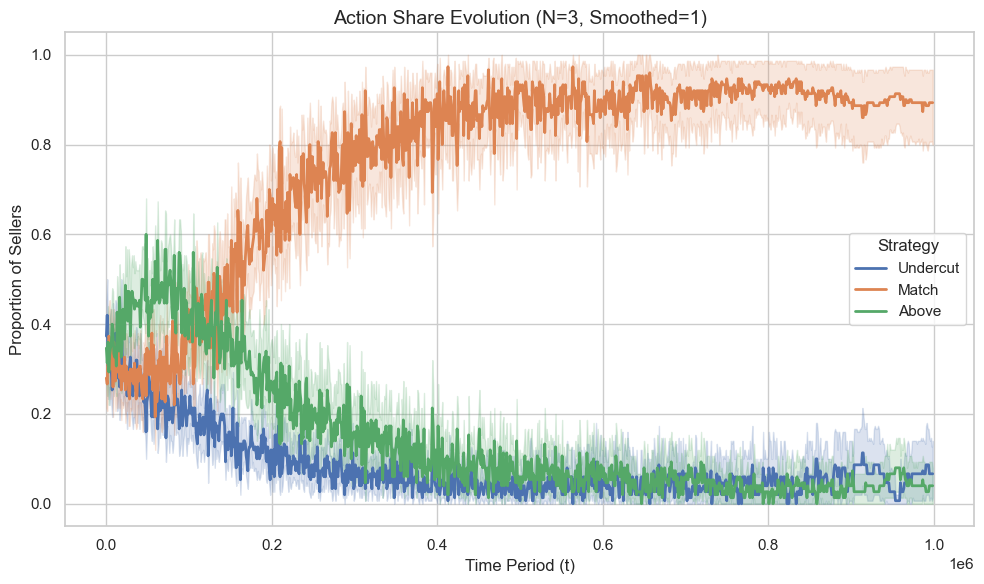

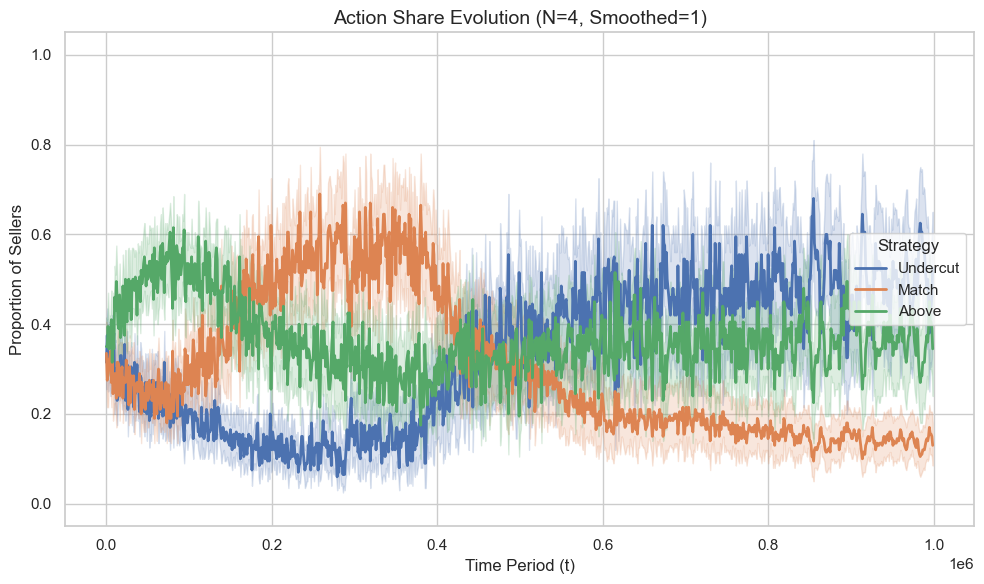

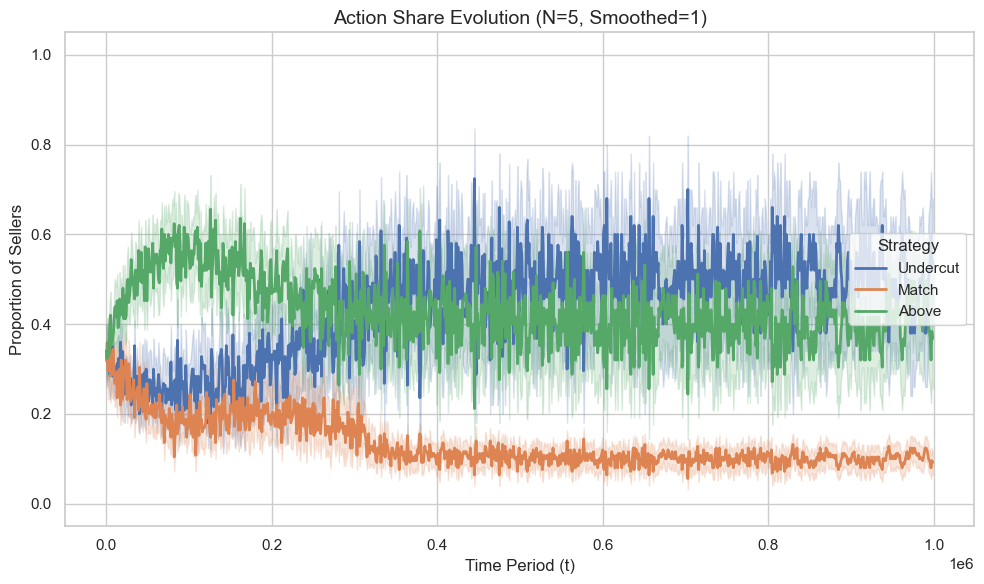

In [27]:
# Plot Action Shares for each N
if df is not None:
    # 获取所有存在的 N
    all_ns = sorted(df["n_sellers"].unique())
    
    print("Plotting Action Shares for each N...")
    
    for n in all_ns:
        plot_action_share_for_specific_n(
            df=df, 
            n_sellers=n, 
            smoothing=1, # 平滑 1 期 (即不平滑)
            ci=95          # 95% 置信区间
        )

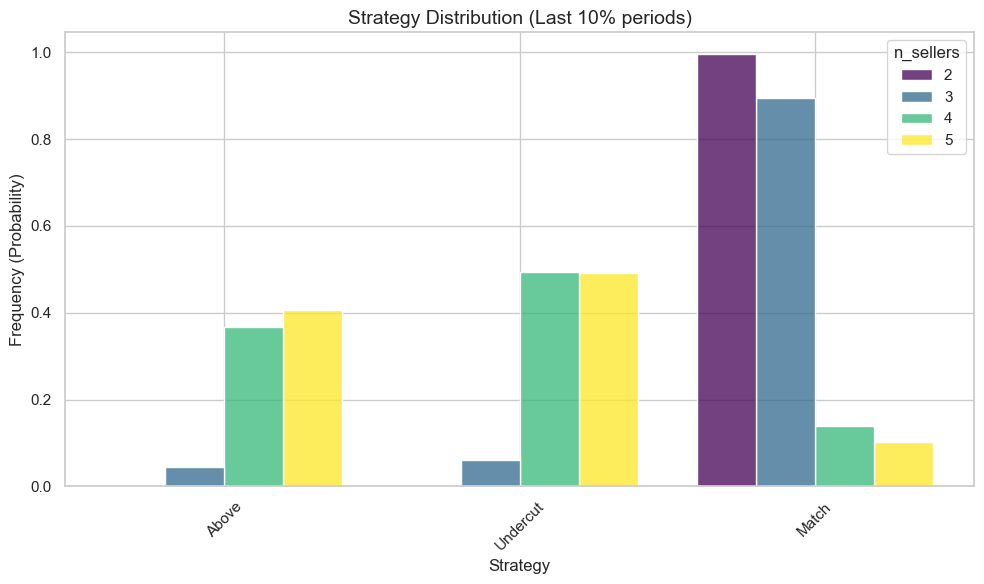

In [28]:
if df is not None and not df.empty:
    plot_action_distribution(df, last_percent=0.1)

In [29]:
# # 查看 N=2 的第 0 次 Run，最后 100 期的价格
# plot_single_run_cycles(EXP_NAME, n_sellers=2, run_id=0, periods=100)

# # 查看 N=4 的第 0 次 Run (看看竞争更激烈时循环是否还在)
# plot_single_run_cycles(EXP_NAME, n_sellers=4, run_id=0, periods=100)